# 02 - Harness Pipeline Demo

**목적**: UCI 실제 데이터 없이, Mock 데이터로 전체 파이프라인을 검증하고 시각화하는 노트북

**파이프라인**: `data_loader` → `preprocessing` (resample → normalize → filter → steady_state) → `features` → 시각화

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import SENSOR_SPECS
from src.preprocessing import resample_to, normalize_minmax, butterworth_filter, extract_steady_state
from src.features import time_domain_features, extract_all_features, TIME_FEATURE_NAMES

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print("Imports OK")

Imports OK


## 1. Mock 센서 데이터 생성

실제 UCI 데이터가 없어도 파이프라인을 검증할 수 있도록, 각 센서 사양에 맞는 가짜 신호를 생성합니다.
- 100Hz 센서 (PS1 등): 6000 타임스텝
- 10Hz 센서 (FS1 등): 600 타임스텝
- 1Hz 센서 (TS1 등): 60 타임스텝

In [2]:
N_CYCLES = 20
TARGET_LENGTH = 600
np.random.seed(42)

sensors_raw = {}
for name, spec in SENSOR_SPECS.items():
    t = np.linspace(0, 60, spec["cols"])
    base_signal = np.sin(2 * np.pi * 0.1 * t)
    noise = np.random.randn(N_CYCLES, spec["cols"]) * 0.3
    sensors_raw[name] = base_signal[np.newaxis, :] + noise

mock_labels = pd.DataFrame({
    "cooler": np.random.choice([3, 20, 100], N_CYCLES),
    "valve": np.random.choice([73, 80, 90, 100], N_CYCLES),
    "pump": np.random.choice([0, 1, 2], N_CYCLES),
    "accumulator": np.random.choice([90, 100, 115, 130], N_CYCLES),
    "stable": np.random.choice([0, 1], N_CYCLES),
})

print("=== Raw Sensor Shapes (before preprocessing) ===")
for name in ["PS1", "FS1", "TS1"]:
    print(f"  {name}: {sensors_raw[name].shape}  ({SENSOR_SPECS[name]['sampling_hz']} Hz)")
print(f"\nLabels: {mock_labels.shape}")

=== Raw Sensor Shapes (before preprocessing) ===
  PS1: (20, 6000)  (100 Hz)
  FS1: (20, 600)  (10 Hz)
  TS1: (20, 60)  (1 Hz)

Labels: (20, 5)


## 2. 전처리 파이프라인 실행 & 시각화

**핵심**: 서로 다른 Hz의 센서들을 동일한 길이(600)로 리샘플링한 뒤, 정규화 → 필터 → 정상상태 추출까지 4단계를 거칩니다.

아래 그래프에서 PS1(100Hz, 원래 6000점)이 각 전처리 단계를 통과하며 어떻게 변화하는지 확인할 수 있습니다.

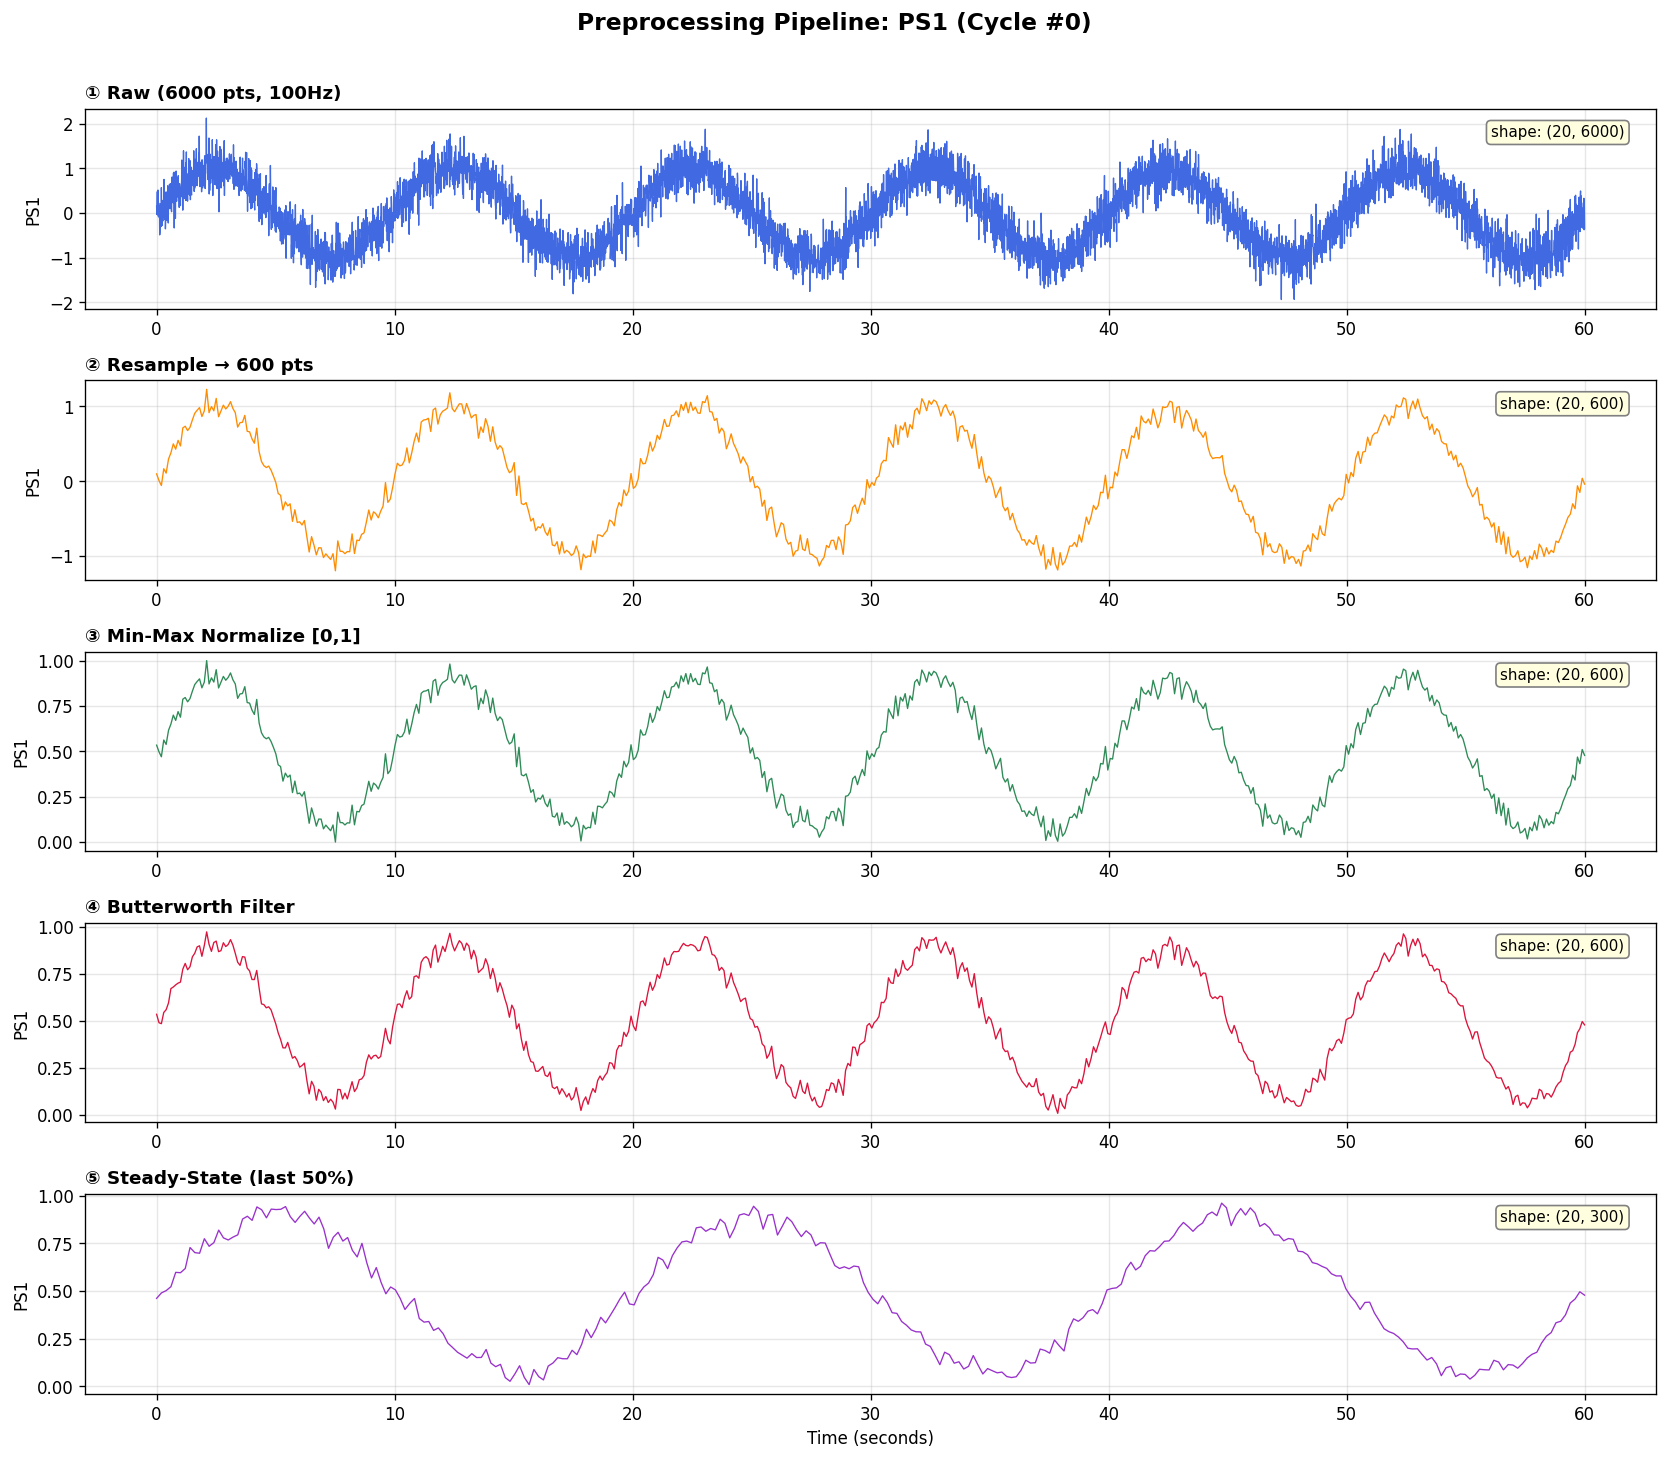


=== Shape 변화 요약 ===
  Raw:          (20, 6000)
  Resampled:    (20, 600)
  Normalized:   (20, 600)
  Filtered:     (20, 600)
  Steady-State: (20, 300)  ← 최종 출력


In [3]:
cycle_idx = 0
sensor_name = "PS1"
raw = sensors_raw[sensor_name]

step1_resampled = resample_to(raw, TARGET_LENGTH)
step2_normalized = normalize_minmax(step1_resampled)
effective_fs = TARGET_LENGTH / 60.0
step3_filtered = butterworth_filter(step2_normalized, cutoff_hz=effective_fs * 0.4, fs=effective_fs)
step4_steady = extract_steady_state(step3_filtered)

stages = [
    ("① Raw (6000 pts, 100Hz)", raw[cycle_idx], "royalblue"),
    ("② Resample → 600 pts", step1_resampled[cycle_idx], "darkorange"),
    ("③ Min-Max Normalize [0,1]", step2_normalized[cycle_idx], "seagreen"),
    ("④ Butterworth Filter", step3_filtered[cycle_idx], "crimson"),
    ("⑤ Steady-State (last 50%)", step4_steady[cycle_idx], "darkorchid"),
]

fig, axes = plt.subplots(5, 1, figsize=(14, 12))
for ax, (title, data, color) in zip(axes, stages):
    t = np.linspace(0, 60, len(data))
    ax.plot(t, data, color=color, linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel(sensor_name)
    ax.grid(True, alpha=0.3)
    
    shape_text = f"shape: ({N_CYCLES}, {len(data)})"
    ax.text(0.98, 0.92, shape_text, transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle(f"Preprocessing Pipeline: {sensor_name} (Cycle #{cycle_idx})",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

print(f"\n=== Shape 변화 요약 ===")
print(f"  Raw:          {raw.shape}")
print(f"  Resampled:    {step1_resampled.shape}")
print(f"  Normalized:   {step2_normalized.shape}")
print(f"  Filtered:     {step3_filtered.shape}")
print(f"  Steady-State: {step4_steady.shape}  ← 최종 출력")

## 3. 3가지 Hz 센서 비교: 리샘플링 전 vs 후

100Hz(PS1), 10Hz(FS1), 1Hz(TS1) 센서가 리샘플링 후 동일한 600 타임스텝으로 통일되는 과정을 나란히 비교합니다.

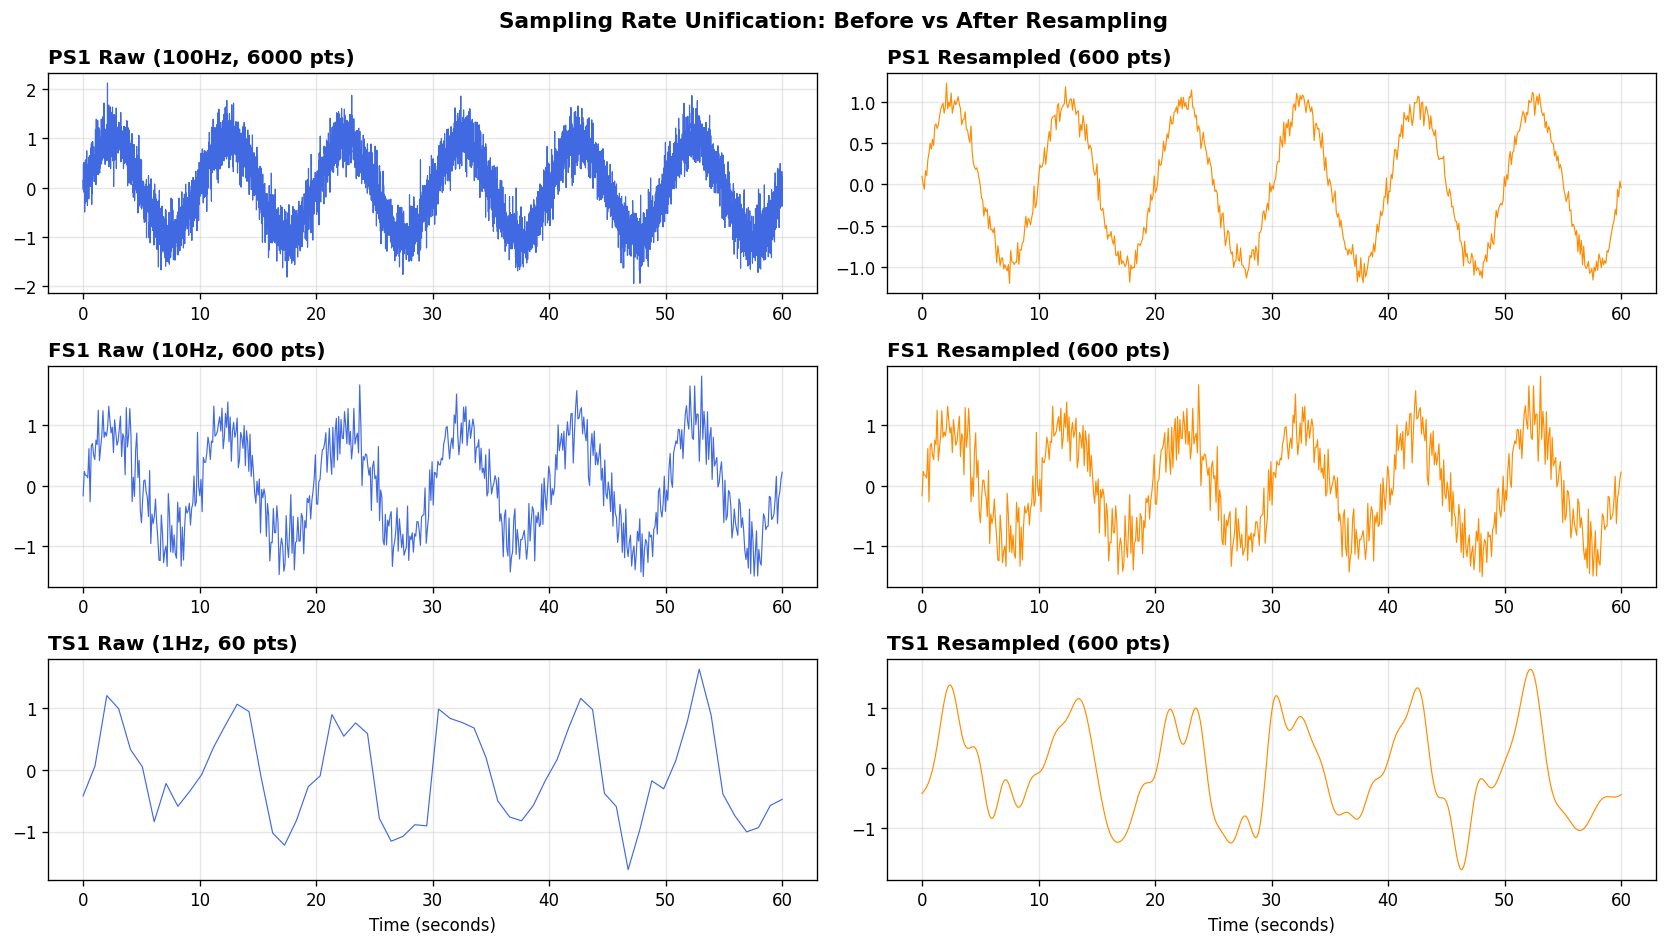

In [4]:
compare_sensors = ["PS1", "FS1", "TS1"]
fig, axes = plt.subplots(3, 2, figsize=(14, 8))

for row, name in enumerate(compare_sensors):
    raw_data = sensors_raw[name][0]
    resampled = resample_to(sensors_raw[name], TARGET_LENGTH)[0]
    hz = SENSOR_SPECS[name]["sampling_hz"]

    t_raw = np.linspace(0, 60, len(raw_data))
    t_res = np.linspace(0, 60, len(resampled))

    axes[row, 0].plot(t_raw, raw_data, color="royalblue", linewidth=0.7)
    axes[row, 0].set_title(f"{name} Raw ({hz}Hz, {len(raw_data)} pts)", fontweight="bold", loc="left")
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(t_res, resampled, color="darkorange", linewidth=0.7)
    axes[row, 1].set_title(f"{name} Resampled ({TARGET_LENGTH} pts)", fontweight="bold", loc="left")
    axes[row, 1].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time (seconds)")

fig.suptitle("Sampling Rate Unification: Before vs After Resampling",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Feature Extraction 결과

전처리된 데이터에서 17개 센서 x 11개 통계 특징 = 187개 feature + 5개 label = **192열 DataFrame**을 추출합니다.

In [5]:
sensors_processed = {}
for name in SENSOR_SPECS:
    resampled = resample_to(sensors_raw[name], TARGET_LENGTH)
    normed = normalize_minmax(resampled)
    filtered = butterworth_filter(normed, cutoff_hz=effective_fs * 0.4, fs=effective_fs)
    sensors_processed[name] = extract_steady_state(filtered)

print("=== Processed Sensor Shapes ===")
shapes = set()
for name, data in sensors_processed.items():
    shapes.add(data.shape)
print(f"  All 17 sensors unified to: {shapes.pop()}")

feature_df = extract_all_features(sensors_processed, mock_labels)
print(f"\n=== Feature DataFrame ===")
print(f"  Shape: {feature_df.shape}")
print(f"  Feature columns: {feature_df.shape[1] - 5}")
print(f"  Label columns: {list(mock_labels.columns)}")
print(f"  NaN count: {feature_df.isnull().sum().sum()}")
feature_df.head()

=== Processed Sensor Shapes ===
  All 17 sensors unified to: (20, 300)

=== Feature DataFrame ===
  Shape: (20, 192)
  Feature columns: 187
  Label columns: ['cooler', 'valve', 'pump', 'accumulator', 'stable']
  NaN count: 0


,PS1_mean,PS1_std,PS1_rms,PS1_peak,PS1_crest_factor,PS1_skewness,PS1_kurtosis,PS1_peak_to_peak,PS1_shape_factor,PS1_impulse_factor,...,SE_kurtosis,SE_peak_to_peak,SE_shape_factor,SE_impulse_factor,SE_clearance_factor,cooler,valve,pump,accumulator,stable
0,0.488928,0.293880,0.570452,0.961527,1.685553,-0.022301,-1.434939,0.953527,1.166742,1.966605,...,-1.098789,0.958890,1.115514,1.781865,1.950947,20,90,0,115,0
1,0.502036,0.275538,0.572679,0.954067,1.665971,-0.002489,-1.454153,0.923663,1.140713,1.900394,...,-1.243201,0.808359,1.111369,1.844952,1.974917,100,73,0,115,1
2,0.493789,0.294785,0.575088,0.986900,1.716085,-0.003011,-1.441113,0.966330,1.164643,1.998627,...,-1.430077,0.814587,1.098563,1.797464,1.903379,20,80,2,100,1
3,0.502160,0.298137,0.583995,0.971439,1.663437,-0.030779,-1.463549,0.946926,1.162967,1.934522,...,-1.441718,1.000000,1.161222,2.006864,2.247623,20,73,2,130,0
4,0.514938,0.299057,0.595480,1.003745,1.685607,-0.008247,-1.434572,0.988265,1.156411,1.949255,...,-1.087767,0.992943,1.159628,2.245300,2.492061,20,100,2,130,1


## 5. 전체 파이프라인 구조도

```
data_loader (17 sensors: 60/600/6000 timesteps)
    │
    ▼
preprocessing
    ├── resample_to(600)          shape: (n, 600)
    ├── normalize_minmax          shape: (n, 600)
    ├── butterworth_filter        shape: (n, 600)
    └── extract_steady_state      shape: (n, 300)
    │
    ▼
features
    └── extract_all_features      shape: DataFrame (n, 192)
         ├── 187 feature columns  (17 sensors × 11 stats)
         └── 5 label columns      (cooler, valve, pump, accumulator, stable)
    │
    ▼
  ML / DL Model (Ready!)
```